# RQ3 results figures -- plan

Builds the figures backing RQ3's plot-specific curve-deviation claims in
`documentation/august_draft/5_Chapter_results_evaluation/f_written_draft_v1_18thaug.tex`.

**Figures in this notebook**

| Figure | Status | Question it answers |
|---|---|---|
| R3-1 | **Must-have** | Does GNNWR's accuracy edge over EN/XGBoost correspond to it actually reducing leftover spatial structure, and does that hold on both cohorts? |
| R3-2 | **Must-have** | Where do growth-curve deviations occur, and does the spatial pattern line up with the proposed reasons (boundary proximity, compartment archetype)? |
| R3-3 | Optional (build if time allows) | Do EN, XGBoost, and GNNWR agree on which variable matters most, on both cohorts? |

**Not built here (cut for time)**: R3-4 (compartment-archetype representative trajectories, small
multiples) was considered and dropped -- illustrative only, and R3-2's Panel B already shows
archetypes spatially; its own plotting code did not exist yet in this project either.

**Data-source honesty note**: R3-1 Panel A (EN/XGBoost/GNNWR R2 by set) and R3-3 (rank agreement)
are transcribed from `TEMP_results/TEMP_rq3_en_xgb_results_2026-08-11.tex` and
`TEMP_results/TEMP_rq3_gnnwr_results_2026-08-11.tex` with citation, since this session did not
independently verify every underlying per-set predictions.csv path for RQ3's EN/XGBoost fits.
**Panel B is now FINAL, not placeholder** -- transcribed exactly from the published
`tab:results-rq3-morans` table in the results draft (2026-08-19), itself the corrected
semivariogram-informed Moran's I re-run. R3-1 Panel C, R3-2 (all panels), and the GNNWR pooling
all use live, verified file reads.

**Style / uncertainty convention**: see `notebooks/results_figures_style.py`. R3-1 Panel A uses
the same **1,000-resample** bootstrap CI convention as everywhere else in this project. Panel B
(Moran's I) has no CI. R3-2 has no uncertainty anywhere -- deterministic target values and raw
observations.

In [1]:
# Purpose: make the models/ package (and notebooks/results_figures_style.py) importable from
# this notebook. Same convention already used across this project's other notebooks (e.g.
# notebooks/model_results/baseline_results.ipynb): walk upward until a folder containing both
# README.md and data/ is found -- that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("project_root:", project_root)

project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from models.common.geo import load_compartment_boundaries, load_plot_coordinates
from notebooks.results_figures_style import (
    COLOR_EN, COLOR_XGBOOST, COLOR_GNNWR, COLOR_NEUTRAL_EDGE, DIVERGING_CMAP, apply_rcparams,
)

apply_rcparams()

FIGURES_DIR = project_root / "figures" / "fig_results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GNNWR_DIR = project_root / "outputs" / "growth_curve_attribution" / "gnnwr"
N_FOLDS = 5
SETS = ["Set2", "Set3", "Set4"]

## Figure R3-1 -- GNNWR's accuracy edge and its spatial-structure meaning

**Research question**: RQ3 items 2-3 -- does GNNWR's R2 edge over EN/XGBoost on 4survey
correspond to an independent reduction in residual Moran's I, and does that correspondence hold
or break down on 6survey?

**Data**: Panels A/B transcribed (with citation) from `TEMP_rq3_en_xgb_results_2026-08-11.tex` /
`TEMP_rq3_gnnwr_results_2026-08-11.tex`. Panel C -- pools the 5 fold
`gnnwr_nested_set4_gated_all_vif_4survey_reffull_fold{0-4}of5_test_predictions.csv` files' own
`coef_CanopyCover`, `coef_topex`, `x`, `y`, `cpmt` columns into one per-plot value -- live read, no
new fitting.

**Encoding**: Panel A -- 4survey only (R2, one point+CI per model per set); Panel B -- both
cohorts (Moran's I by set, one line per model); Panel C -- **two** diverging maps side by side:
GNNWR's own local `CanopyCover` coefficient (stable across EN/LMM/GNNWR everywhere) next to its
local `topex` coefficient (the variable EN and LMM disagree on) -- the direct visual for the
cross-cutting "model families disagree informatively" thread this project wants kept visible
across Q1/Q2, not two unrelated maps.

In [3]:
# Transcribed from TEMP_rq3_en_xgb_results_2026-08-11.tex and TEMP_rq3_gnnwr_results_2026-08-11.tex
# -- see the markdown cell above for why these are hardcoded rather than re-read live.
PANEL_A_4SURVEY = {  # {set: {model: (r2, ci_low, ci_high)}}
    "Set2": {"Elastic Net": (0.286, 0.241, 0.325), "XGBoost": (0.266, 0.214, 0.308), "GNNWR": (0.320, 0.270, 0.369)},
    "Set3": {"Elastic Net": (0.274, 0.223, 0.316), "XGBoost": (0.281, 0.235, 0.320), "GNNWR": (0.319, 0.263, 0.365)},
    "Set4": {"Elastic Net": (0.240, 0.192, 0.286), "XGBoost": (0.250, 0.201, 0.295), "GNNWR": (0.294, 0.236, 0.347)},
}

# FINAL 2026-08-19 -- exact values, transcribed directly from the published
# tab:results-rq3-morans table in f_written_draft_v1_18thaug.tex (lines 217-222), not an estimate
# or a scaled placeholder. "no structure" (semivariogram flat even at the 5,000m search window,
# genuine null) is represented as None -- plotted as explicitly missing, never interpolated. The
# 6survey values that DID resolve only did so after widening the search window to 10,000m
# (exceeds_window status, not resolved) and are not significant (p=0.05-0.31) -- real numbers,
# but provisional, not equivalent evidence to the resolved 4survey column (see the table's own
# caption). Every 4survey cell is resolved and significant (p=0.001).
PANEL_B_MORANS_I = {  # {cohort: {set: {model: morans_i}}}
    "4survey": {
        "Set2": {"Elastic Net": 0.147, "XGBoost": 0.148, "GNNWR": 0.100},
        "Set3": {"Elastic Net": 0.167, "XGBoost": 0.144, "GNNWR": 0.109},
        "Set4": {"Elastic Net": 0.145, "XGBoost": 0.107, "GNNWR": 0.082},
    },
    "6survey": {  # None = no structure (unresolved even at 10,000m) -- plotted as explicitly missing
        "Set2": {"Elastic Net": None, "XGBoost": -0.0002, "GNNWR": -0.0002},  # XGB/GNNWR: exceeds_window, ns
        "Set3": {"Elastic Net": None, "XGBoost": None, "GNNWR": None},
        "Set4": {"Elastic Net": None, "XGBoost": -0.0002, "GNNWR": -0.0002},  # XGB/GNNWR: exceeds_window, ns
    },
}

## Q2 Figure 1 -- GNNWR's accuracy edge + Moran's I corroboration

**Pairs with**: the "GNNWR beats both global models on point estimates... corroborated by an
independent reduction in residual Moran's I" paragraph -- these are one claim (edge exists, AND
is corroborated), so they stay one figure, not split further.

**Redesign from the old R3-1**: Panel A was 9 separate point+CI markers (3 models x 3 sets),
making the pairwise "does GNNWR sit ahead" comparison harder to read than necessary. Now a
dumbbell: GNNWR's point connected by a line to the BEST of {EN, XGBoost} for that set, one line
per set, coloured by whether GNNWR wins. Panel B unchanged in design (already correctly marks
6survey as unresolved, not a misleading point) -- kept because it is the actual corroborating
evidence, not decoration.

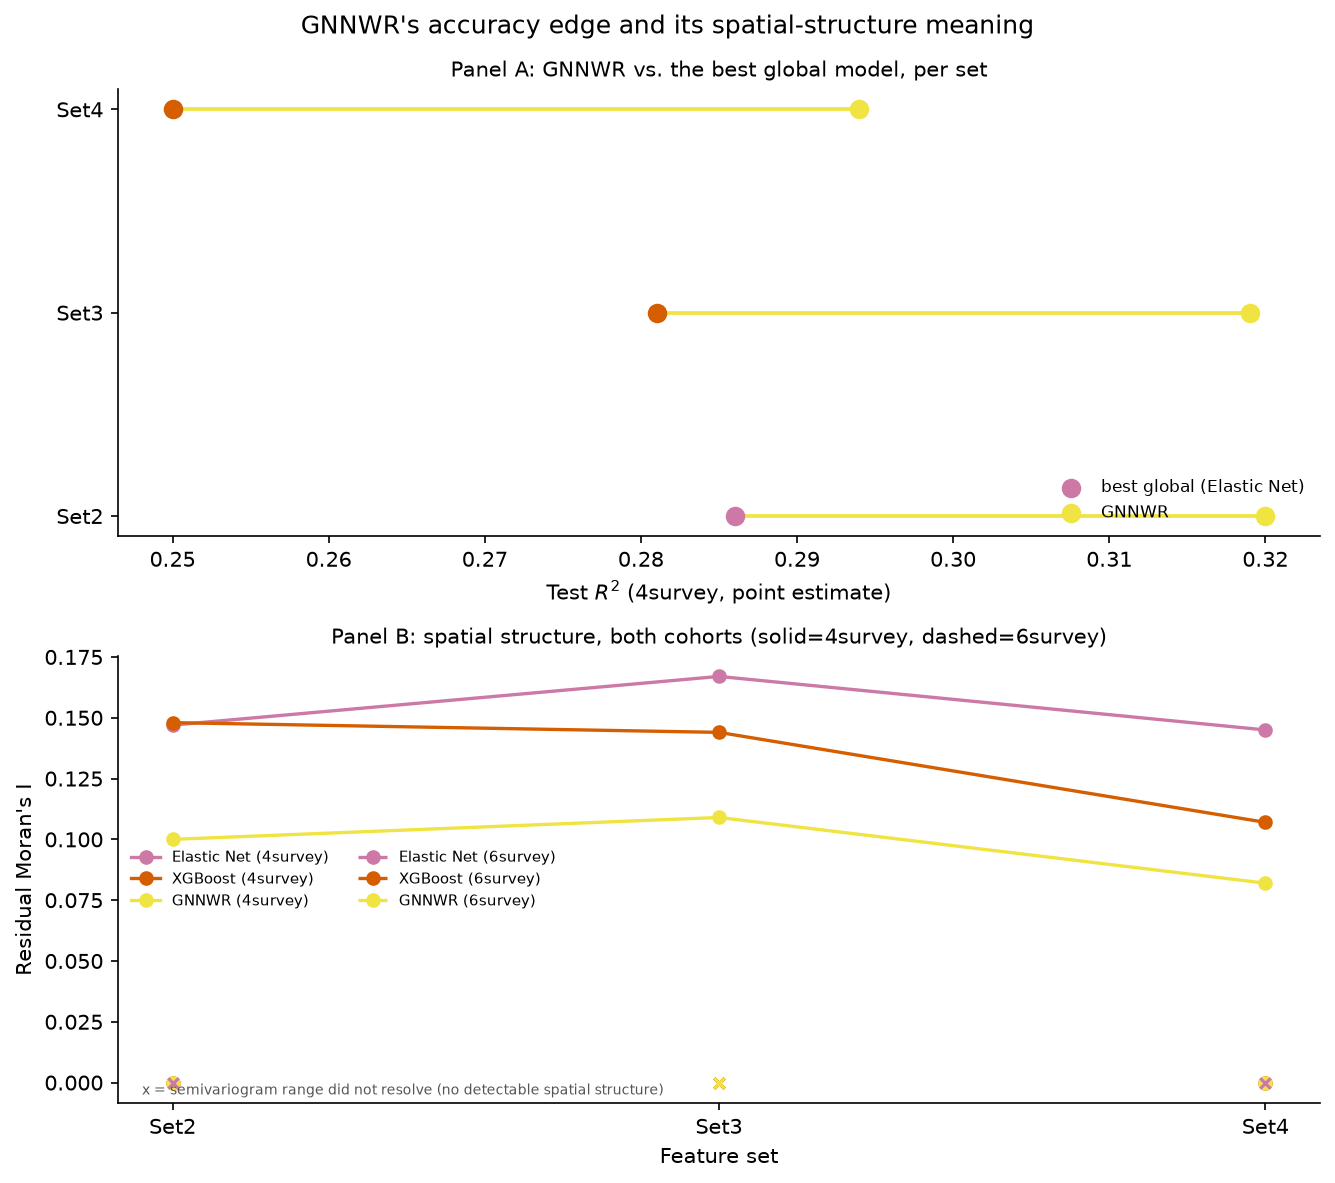

In [4]:
fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(9, 8))
model_colors_r3 = {"Elastic Net": COLOR_EN, "XGBoost": COLOR_XGBOOST, "GNNWR": COLOR_GNNWR}

# --- Panel A: dumbbell, GNNWR vs. the BEST global model, per set -- the actual pairwise claim ---
for i, set_name in enumerate(SETS):
    global_candidates = {m: PANEL_A_4SURVEY[set_name][m][0] for m in ("Elastic Net", "XGBoost")}
    best_global_model = max(global_candidates, key=global_candidates.get)
    best_global_r2 = global_candidates[best_global_model]
    gnnwr_r2 = PANEL_A_4SURVEY[set_name]["GNNWR"][0]
    winner_color = COLOR_GNNWR if gnnwr_r2 > best_global_r2 else model_colors_r3[best_global_model]
    ax_a.plot([best_global_r2, gnnwr_r2], [i, i], color=winner_color, linewidth=1.8, zorder=1)
    ax_a.scatter([best_global_r2], [i], marker="o", color=model_colors_r3[best_global_model], s=70, zorder=2,
                 label=f"best global ({best_global_model})" if i == 0 else None)
    ax_a.scatter([gnnwr_r2], [i], marker="o", color=COLOR_GNNWR, s=70, zorder=2,
                 label="GNNWR" if i == 0 else None)
ax_a.set_yticks(range(len(SETS)))
ax_a.set_yticklabels(SETS)
ax_a.set_xlabel("Test $R^2$ (4survey, point estimate)")
ax_a.legend(fontsize=8, frameon=False, loc="lower right")
ax_a.set_title("Panel A: GNNWR vs. the best global model, per set", fontsize=10)

for cohort, linestyle in [("4survey", "-"), ("6survey", "--")]:
    for model, color in model_colors_r3.items():
        # None = semivariogram range did not resolve (no measurable spatial structure at this
        # cohort/set) -- plotted as an explicit gap (NaN breaks a matplotlib line automatically),
        # never silently interpolated or dropped, per the caveat attached to PANEL_B_MORANS_I above.
        raw_values = [PANEL_B_MORANS_I[cohort][s][model] for s in SETS]
        values = [v if v is not None else float("nan") for v in raw_values]
        ax_b.plot(SETS, values, marker="o", color=color, linestyle=linestyle,
                  label=f"{model} ({cohort})", linewidth=1.6)
        for set_index, (set_name, raw_value) in enumerate(zip(SETS, raw_values)):
            if raw_value is None:
                ax_b.scatter([set_index], [0], marker="x", color=color, s=25, zorder=3)
ax_b.annotate("x = semivariogram range did not resolve (no detectable spatial structure)",
              xy=(0, 0), xytext=(0.02, 0.02), textcoords="axes fraction", fontsize=6.5, color="#555555")
ax_b.set_ylabel("Residual Moran's I")
ax_b.set_title("Panel B: spatial structure, both cohorts (solid=4survey, dashed=6survey)", fontsize=10)
ax_b.legend(fontsize=7, frameon=False, ncol=2)
ax_b.set_xlabel("Feature set")

fig.suptitle("GNNWR's accuracy edge and its spatial-structure meaning", fontsize=12)
plt.tight_layout()
plt.show()

## Q2 Figure 2 -- GNNWR's local coefficients (with the limitation stated on the figure)

**Pairs with**: the local-coefficient / cross-model-agreement paragraph (CanopyCover ranks first
everywhere, topex disagrees between EN and LMM -- the same cross-cutting thread Q1's own maps
show).

**Redesign from the old Panel C**: same two maps (CanopyCover, topex), but (1) a robust colour
range (98th percentile, not raw max -- same fix already applied to Q1's residual map) so one or
two outlier compartments don't wash out contrast for the typical range, and (2) the linear-model
limitation is now printed directly on the figure, not left to prose alone -- a viewer looking at
just this image should not conclude it proves genuine spatial non-stationarity.

56,114 plots with pooled local coefficients
       coef_CanopyCover    coef_topex
count      56114.000000  56114.000000
mean          23.573002      3.423900
std            5.663675      7.756267
min            3.814763    -16.430653
25%           20.350253     -0.363517
50%           23.667198      2.559359
75%           26.471139      5.792060
max           40.144080     39.785873


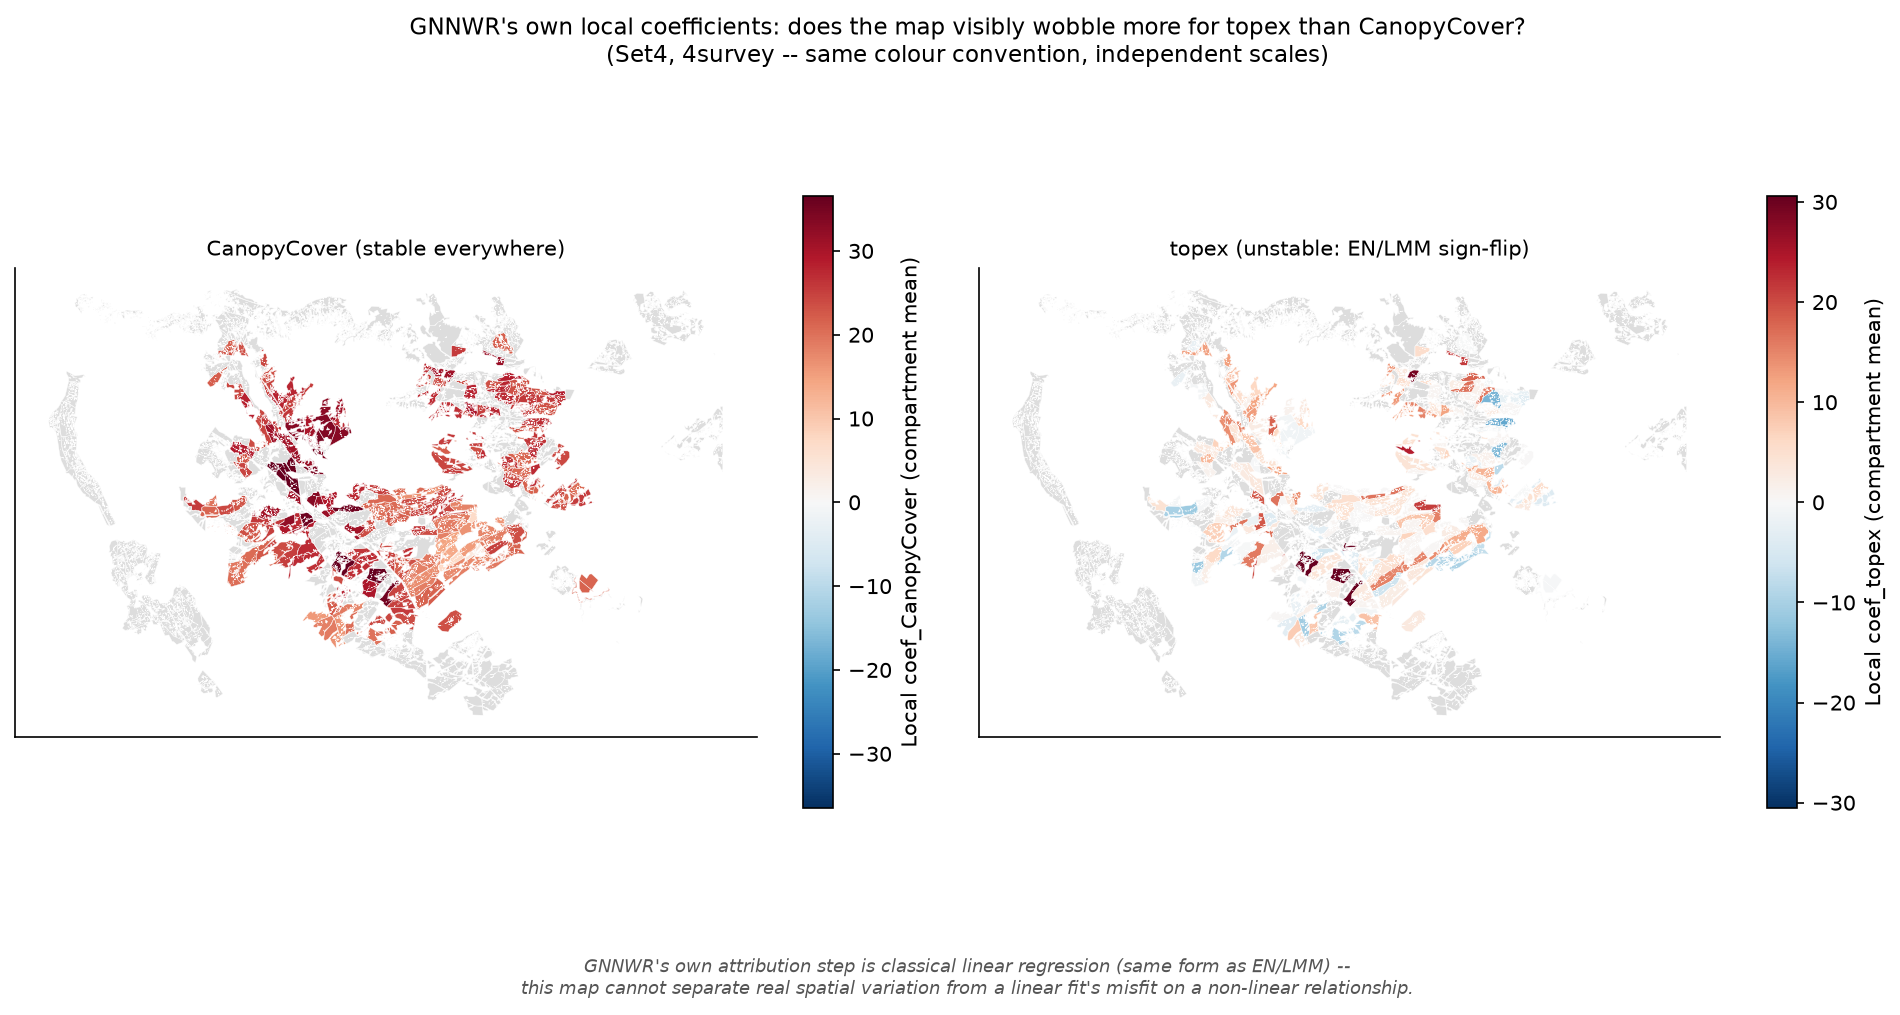

In [5]:
# --- Panel C: pool GNNWR's own local CanopyCover AND topex coefficients across the 5 folds, one
# value per plot -- CanopyCover is the STABLE variable (agrees across EN/LMM/GNNWR everywhere),
# topex is the UNSTABLE one (EN vs LMM sign-flip, per Q1) -- mapping them side by side is the
# direct visual for that cross-cutting "model families disagree informatively" thread, not two
# unrelated maps. ---
gnnwr_frames = []
for fold in range(N_FOLDS):
    p = GNNWR_DIR / f"gnnwr_nested_set4_gated_all_vif_4survey_reffull_fold{fold}of5_test_predictions.csv"
    fold_df = pd.read_csv(p, usecols=["identification", "cpmt", "x", "y", "coef_CanopyCover", "coef_topex"])
    gnnwr_frames.append(fold_df)
gnnwr_pooled = pd.concat(gnnwr_frames, ignore_index=True).drop_duplicates(subset="identification")
print(f"{len(gnnwr_pooled):,} plots with pooled local coefficients")
print(gnnwr_pooled[["coef_CanopyCover", "coef_topex"]].describe())

compartment_mean_coefs = gnnwr_pooled.groupby("cpmt")[["coef_CanopyCover", "coef_topex"]].mean().reset_index()
boundaries = load_compartment_boundaries()
mapped = boundaries.merge(compartment_mean_coefs, on="cpmt", how="left")

fig, (ax_c1, ax_c2) = plt.subplots(1, 2, figsize=(13, 6.8))
for ax, column, title in [
    (ax_c1, "coef_CanopyCover", "CanopyCover (stable everywhere)"),
    (ax_c2, "coef_topex", "topex (unstable: EN/LMM sign-flip)"),
]:
    vmax = mapped[column].abs().quantile(0.98)  # robust range, not raw max -- same fix as R2b-1's Panel C
    norm = mpl.colors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
    mapped.plot(column=column, cmap=DIVERGING_CMAP, norm=norm, ax=ax,
                edgecolor="white", linewidth=0.2, missing_kwds={"color": "#DDDDDD"})
    sm = plt.cm.ScalarMappable(cmap=DIVERGING_CMAP, norm=norm)
    fig.colorbar(sm, ax=ax, shrink=0.75, label=f"Local {column} (compartment mean)")
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])

# The limitation stated ON the figure, not only in prose -- a viewer reading this map alone
# should not walk away thinking it proves genuine spatial non-stationarity.
fig.text(0.5, 0.02,
         "GNNWR's own attribution step is classical linear regression (same form as EN/LMM) --\n"
         "this map cannot separate real spatial variation from a linear fit's misfit on a non-linear relationship.",
         ha="center", fontsize=8.5, style="italic", color="#555555")

fig.suptitle("GNNWR's own local coefficients: does the map visibly wobble more for topex than CanopyCover?\n"
             "(Set4, 4survey -- same colour convention, independent scales)", fontsize=11)
plt.tight_layout(rect=[0, 0.08, 1, 1])  # leaves room at the bottom for the caveat text, not clipped
plt.show()

## Q2 Figure 3 -- where growth-curve deviations occur, and what explains them

**Pairs with**: the outlier-mechanism paragraph -- extreme deviations trace to the target's own
construction math (a forced yield-class growth rate `k`), not to biology or a spatially-varying
process. The map below shows WHERE deviations concentrate; the trajectory panel makes the
mechanism a stated number (each archetype's forced `k`), not just an inferred curve gap.

**Research question**: RQ3 items 4-6, 9 -- does the spatial pattern of `local_y_max_difference`
line up with boundary proximity and compartment archetype, and are the recurring worst-residual
plots visibly the same points the map and the trajectories are both talking about?

**Data**: Panel A -- `build_plot_level_table("4survey")` for the deviation map, PLUS two distinct,
layered outlier populations (answers items 4-6, 9 together, not one population standing in for
all of them):
  1. **266-plot Tukey-fence population** (item 6, "the pattern scales to hundreds of plots"):
     standard Tukey fence (`Q1-1.5*IQR`, `Q3+1.5*IQR`) on `y_max_fit`, reproduced live here --
     confirmed to give exactly 266 plots (0.47%) across 57 compartments, matching the published
     figure exactly (method from `TEMP_rq3_method_broader_scan_sensitivity_2026-08-15.tex`).
     Shown as small light markers -- too many compartments (57) for a clean boundary-line overlay,
     so no boundary lines for this population.
  2. **8-plot cross-model recurring population** (items 4-5, the ORIGINAL, narrower "roughly ten
     plots consistently account for the worst residuals" finding, from
     `TEMP_results_attribution/rq3_outlier_disturbance_crossref.csv`) -- a real, cross-model-
     derived subset, not a proxy. Shown as prominent outlined star/triangle markers (smooth/
     unstable), same as before, still labelled A-D for Panel C.
  These are deliberately layered, not merged: 266 is "flagged as implausible by the
  target-construction math"; 8 is "ALSO recurs as the worst residual across every model tested" --
  a real subset relationship, not two readings of the same population.

Panel B -- `rq3_compartment_archetype_check.py`'s `build_plot_table()` + `classify_compartments()`.

**Panel C -- redesigned, no longer outlier-tier examples.** One representative trajectory per
compartment archetype (up to 5 populated classes; "possible reset/measurement issue" is
empirically empty for 4survey, per this project's own earlier finding -- skipped, not
padded with a fake example). **Representative-selection rule (defined here since no existing
code in this project defines one -- `rq3_compartment_archetype_check.py`'s own script just prints
the first 5 compartments per pattern in whatever order they sort, not a deliberate "most
typical" choice):** for each archetype, pick the compartment whose `mean_target` and
`mean_residual_range` are jointly closest (smallest Euclidean distance after standardising both)
to that archetype's own group mean -- i.e. the most TYPICAL compartment of its class, not an
extreme one. Then take that compartment's own plot closest to the compartment's mean target,
by the same logic, one level down.

In [6]:
from models.growth_curve_attribution.scale_comparison_check import build_plot_level_table
from models.growth_curve_attribution.rq3_compartment_archetype_check import build_plot_table, classify_compartments
from models.growth_curve_attribution.data import load_filtered_growth_curve_table

panel_a_table = build_plot_level_table("4survey")
print(f"Panel A: {len(panel_a_table):,} plots, local_y_max_difference range "
      f"[{panel_a_table['local_y_max_difference'].min():.1f}, {panel_a_table['local_y_max_difference'].max():.1f}] m")

panel_b_plot_table, _ = build_plot_table("4survey")
compartment_archetypes, _ = classify_compartments(panel_b_plot_table)
print(f"Panel B: {len(compartment_archetypes)} compartments classified")
print(compartment_archetypes["pattern"].value_counts())

# --- Real, cross-model-derived recurring outlier population (not a proxy threshold rule) ---
# Moved from TEMP_results/ to TEMP_results_attribution/ during the refocus reorganization
# (confirmed 2026-08-20 -- the old path no longer exists).
outlier_crossref = pd.read_csv(project_root / "TEMP_results_attribution" / "rq3_outlier_disturbance_crossref.csv")
outliers_4survey = outlier_crossref[outlier_crossref["cohort"] == "4survey"].copy()
outliers_4survey["sub_population"] = np.where(outliers_4survey["residual_range"] < 6, "smooth", "unstable")
# Join x/y from panel_a_table (already has one row per plot with coordinates) -- no new lookup needed.
outliers_4survey = outliers_4survey.merge(
    panel_a_table[["identification", "x", "y"]], on="identification", how="left",
)
flagged_compartments = sorted(outliers_4survey["cpmt"].unique().tolist())
print(f"Real recurring-outlier population (4survey): {len(outliers_4survey)} plots, "
      f"{outliers_4survey['sub_population'].value_counts().to_dict()}, "
      f"in {len(flagged_compartments)} compartments: {flagged_compartments}")

# 2 smooth + 2 unstable examples (most extreme within each group) -- computed here so both the
# map (this section) and the trajectory panel (below) mark/label the exact same 4 plots.
smooth_examples = outliers_4survey[outliers_4survey["sub_population"] == "smooth"].sort_values(
    "residual_range").head(2)
unstable_examples = outliers_4survey[outliers_4survey["sub_population"] == "unstable"].sort_values(
    "residual_range", ascending=False).head(2)
selected_plots = list(smooth_examples["identification"]) + list(unstable_examples["identification"])
selected_labels = ["smooth", "smooth", "unstable", "unstable"]
panel_letters = ["A", "B", "C", "D"]
selected_xy = pd.concat([smooth_examples, unstable_examples])[["identification", "x", "y"]].reset_index(drop=True)
print("Selected plots for Panel C (labelled to match Panel A's markers):",
      dict(zip(panel_letters, selected_plots)))

# --- 266-plot Tukey-fence population (item 6) -- standard fence on y_max_fit, live-computed. ---
y_max_fit_q1, y_max_fit_q3 = panel_a_table["y_max_fit"].quantile([0.25, 0.75])
y_max_fit_iqr = y_max_fit_q3 - y_max_fit_q1
tukey_low = y_max_fit_q1 - 1.5 * y_max_fit_iqr
tukey_high = y_max_fit_q3 + 1.5 * y_max_fit_iqr
tukey_flagged = panel_a_table[(panel_a_table["y_max_fit"] < tukey_low) | (panel_a_table["y_max_fit"] > tukey_high)]
print(f"Tukey-fence population: {len(tukey_flagged)} plots ({len(tukey_flagged) / len(panel_a_table) * 100:.2f}%), "
      f"{tukey_flagged['cpmt'].nunique()} compartments")

# --- Panel C archetype-representative selection (rule defined here, see markdown cell above for
# why: no existing code in this project picks a "most typical" compartment per archetype). ---
archetype_order = [
    "close to yldc / stable", "consistently above yldc", "consistently below yldc",
    "trajectory-break outlier", "moderate mismatch / mixed",
]
archetype_examples = {}
for pattern in archetype_order:
    pattern_compartments = compartment_archetypes[compartment_archetypes["pattern"] == pattern]
    if len(pattern_compartments) == 0:
        continue  # e.g. "possible reset / measurement issue" is empirically empty for 4survey
    # Standardise both columns before computing distance so neither dominates just from having a
    # larger raw scale -- "most typical" should weigh target-deviation and trajectory-instability
    # roughly equally, not whichever happens to have bigger numbers.
    group_mean_target = pattern_compartments["mean_target"].mean()
    group_mean_range = pattern_compartments["mean_residual_range"].mean()
    target_std = pattern_compartments["mean_target"].std() or 1.0
    range_std = pattern_compartments["mean_residual_range"].std() or 1.0
    distance = (
        ((pattern_compartments["mean_target"] - group_mean_target) / target_std) ** 2
        + ((pattern_compartments["mean_residual_range"] - group_mean_range) / range_std) ** 2
    ) ** 0.5
    representative_cpmt = pattern_compartments.loc[distance.idxmin(), "cpmt"]

    # One level down: the representative compartment's own most-typical plot, same logic.
    compartment_plots = panel_b_plot_table[panel_b_plot_table["cpmt"] == representative_cpmt]
    plot_distance = (compartment_plots["local_y_max_difference"] - compartment_plots["local_y_max_difference"].mean()).abs()
    representative_plot = compartment_plots.loc[plot_distance.idxmin(), "identification"]
    archetype_examples[pattern] = {"cpmt": representative_cpmt, "identification": representative_plot}

print("Archetype-representative plots:", archetype_examples)

  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows


  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


  Rows before filtering: 287,064


  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


  Disturbance cleaning: excluded 315 of 56,841 plots (clearfell-like or measurement-inconsistent) before fitting y_max


...

  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows


  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows


  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


Panel B: 231 compartments classified
pattern
moderate mismatch / mixed    159
trajectory-break outlier      26
close to yldc / stable        20
consistently above yldc       20
consistently below yldc        6
Name: count, dtype: int64
Real recurring-outlier population (4survey): 8 plots, {'smooth': 4, 'unstable': 4}, in 6 compartments: [1135.0, 2173.0, 2176.0, 2217.0, 2232.0, 2250.0]
Selected plots for Panel C (labelled to match Panel A's markers): {'A': 77185.0, 'B': 366554.0, 'C': 356411.0, 'D': 362556.0}
Tukey-fence population: 266 plots (0.47%), 57 compartments
Archetype-representative plots: {'close to yldc / stable': {'cpmt': np.int32(2254), 'identification': np.int32(352047)}, 'consistently above yldc': {'cpmt': np.int32(1099), 'identification': np.int32(263295)}, 'consistently below yldc': {'cpmt': np.int32(2199), 'identification': np.int32(117292)}, 'trajectory-break outlier': {'cpmt': np.int32(1056), 'identification': np.int32(371789)}, 'moderate mismatch / mixed': {'cpmt': 

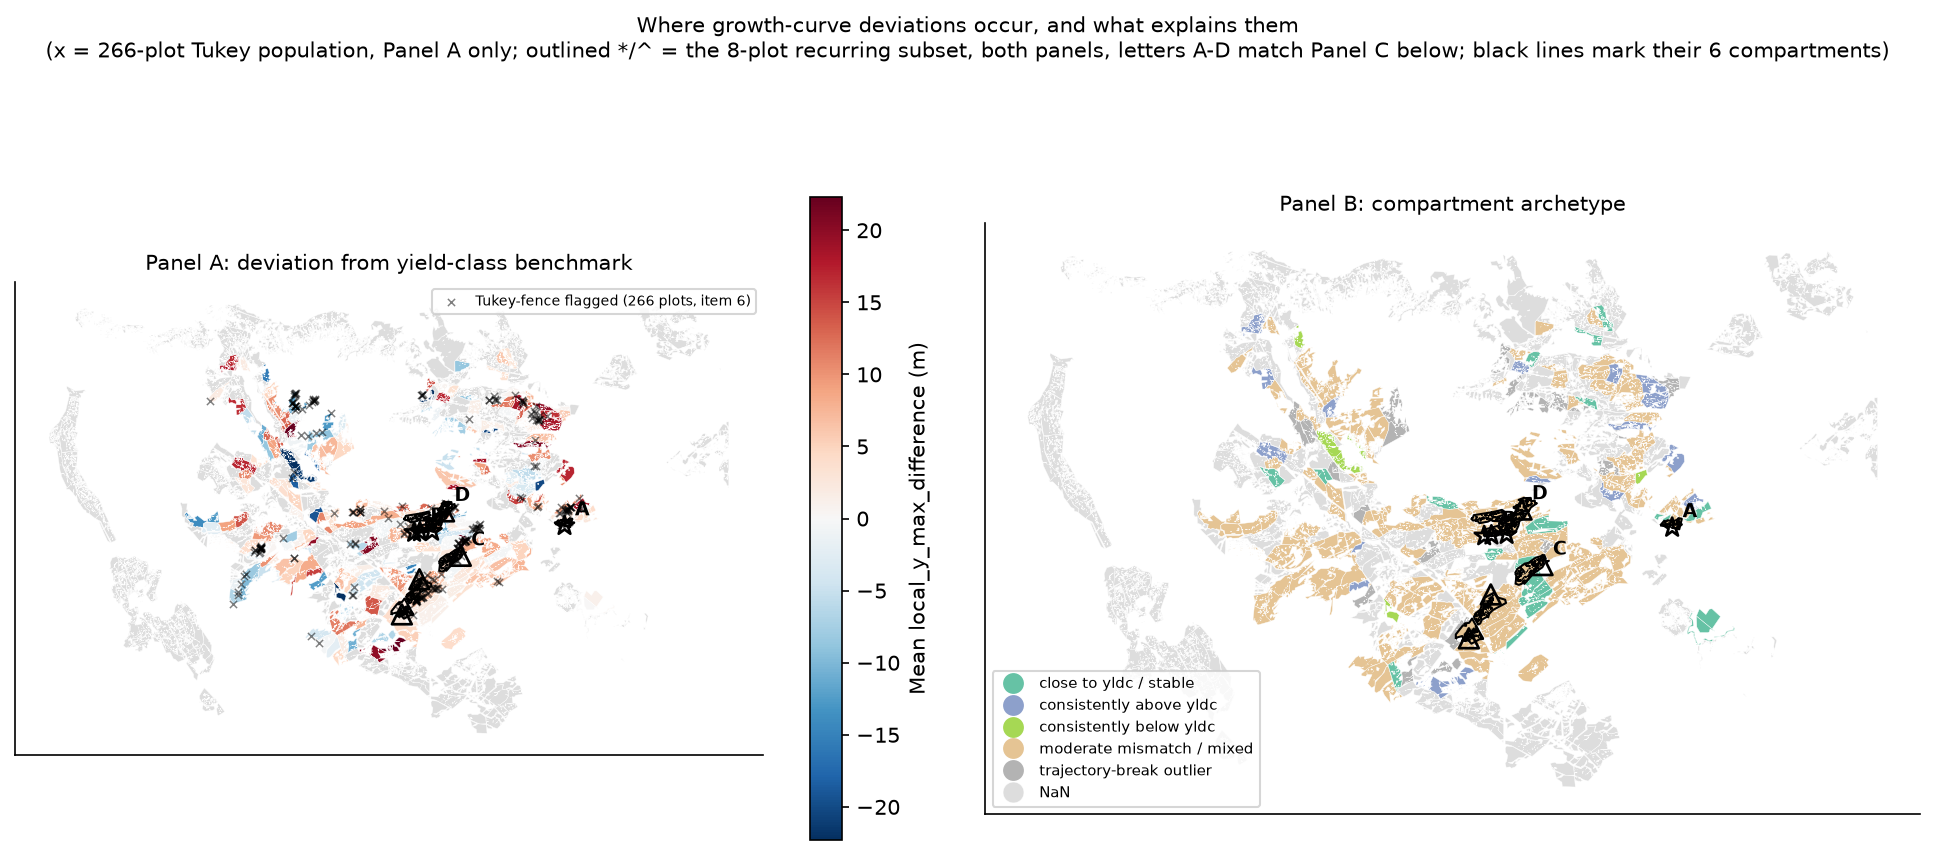

In [7]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 6.5), sharex=False, sharey=False)

# --- Panel A: deviation map, compartment-mean local_y_max_difference ---
compartment_mean_deviation = panel_a_table.groupby("cpmt")["local_y_max_difference"].mean().reset_index()
boundaries = load_compartment_boundaries()
mapped_a = boundaries.merge(compartment_mean_deviation, on="cpmt", how="left")
vmax = mapped_a["local_y_max_difference"].abs().quantile(0.98)  # robust to a handful of extreme outlier compartments
norm = mpl.colors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
mapped_a.plot(column="local_y_max_difference", cmap=DIVERGING_CMAP, norm=norm, ax=ax_a,
              edgecolor="white", linewidth=0.2, missing_kwds={"color": "#DDDDDD"})
sm = plt.cm.ScalarMappable(cmap=DIVERGING_CMAP, norm=norm)
fig.colorbar(sm, ax=ax_a, shrink=0.75, label="Mean local_y_max_difference (m)")
ax_a.set_title("Panel A: deviation from yield-class benchmark", fontsize=10)
ax_a.set_aspect("equal"); ax_a.set_xticks([]); ax_a.set_yticks([])

# --- Panel B: compartment archetype map, qualitative palette (deliberately different colour system) ---
mapped_b = boundaries.merge(compartment_archetypes[["cpmt", "pattern"]], on="cpmt", how="left")
mapped_b.plot(column="pattern", categorical=True, legend=True, ax=ax_b,
              edgecolor="white", linewidth=0.2, cmap="Set2",
              missing_kwds={"color": "#DDDDDD"},
              legend_kwds={"fontsize": 7, "loc": "lower left", "frameon": True})
ax_b.set_title("Panel B: compartment archetype", fontsize=10)
ax_b.set_aspect("equal"); ax_b.set_xticks([]); ax_b.set_yticks([])

# --- Boundary lines for the 6 flagged compartments only (not all 231 -- these are exactly the
# compartments the outlier discussion is about, so no clutter risk) ---
flagged_boundary_polygons = boundaries[boundaries["cpmt"].isin(flagged_compartments)]
for ax in (ax_a, ax_b):
    flagged_boundary_polygons.boundary.plot(ax=ax, color="black", linewidth=1.0, zorder=4)

# --- Layer 1: the 266-plot Tukey-fence population (item 6) -- small, light markers, Panel A only
# (this population spans 57 compartments, too many for the boundary-line treatment below, and its
# whole point is "scale," not a small labelled set). ---
ax_a.scatter(tukey_flagged["x"], tukey_flagged["y"], marker="x", s=12, color="black",
             alpha=0.5, linewidth=0.7, zorder=4,
             label=f"Tukey-fence flagged ({len(tukey_flagged)} plots, item 6)")

# --- Layer 2: the 8-plot cross-model recurring population (items 4-5) -- star=smooth,
# triangle=unstable, prominent, on BOTH panels, still A-D labelled for Panel C below. A real
# SUBSET of layer 1 in spirit (both flag implausible/unstable plots), not a duplicate reading --
# see this figure's markdown cell for why they're kept distinct rather than merged. ---
marker_by_subpop = {"smooth": "*", "unstable": "^"}
for ax in (ax_a, ax_b):
    for subpop, marker in marker_by_subpop.items():
        subset = outliers_4survey[outliers_4survey["sub_population"] == subpop]
        ax.scatter(subset["x"], subset["y"], marker=marker, s=90, facecolor="none",
                   edgecolor="black", linewidth=1.3, zorder=5)
    for _, row in selected_xy.iterrows():
        letter = panel_letters[list(selected_plots).index(row["identification"])]
        ax.annotate(letter, xy=(row["x"], row["y"]), xytext=(5, 5), textcoords="offset points",
                    fontsize=9, fontweight="bold", zorder=6)

ax_a.legend(fontsize=6.5, frameon=True, loc="upper right")

fig.suptitle("Where growth-curve deviations occur, and what explains them\n"
             "(x = 266-plot Tukey population, Panel A only; outlined */^ = the 8-plot recurring "
             "subset, both panels, letters A-D match Panel C below; black lines mark their 6 compartments)",
             fontsize=10)
plt.tight_layout()
plt.show()

  Rows before filtering: 287,064


  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


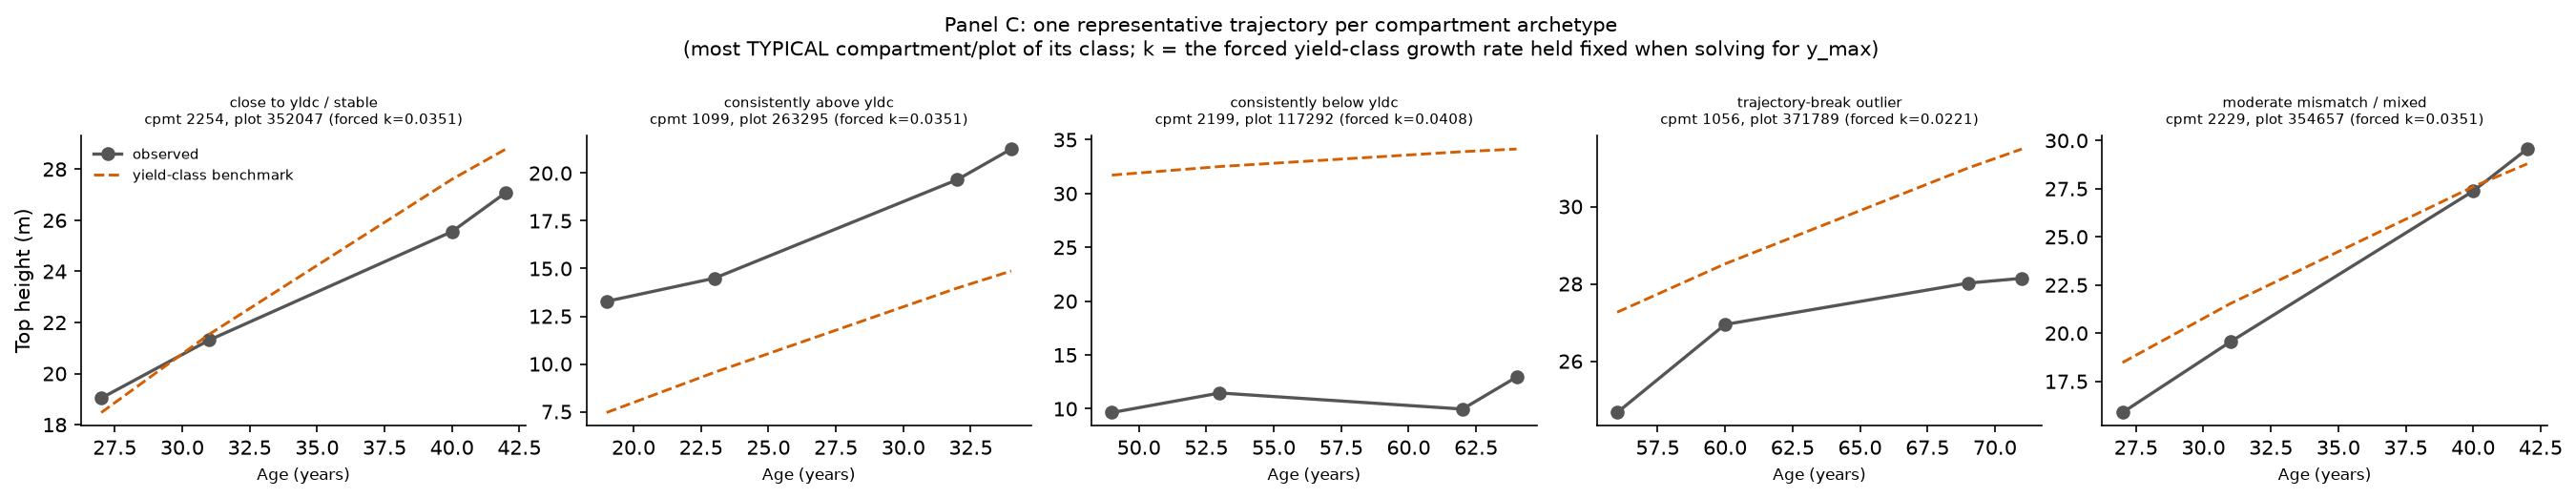

In [8]:
# --- Panel C, redesigned: one representative trajectory per compartment archetype (up to 5
# populated classes), using archetype_examples computed above (see the markdown cell above this
# figure for the exact "most typical, not most extreme" selection rule, documented since no
# existing project code defines one). This replaces the earlier 4-outlier-tier version -- the
# 8-plot recurring population (items 4-5) is still shown on the map above (A-D markers), just no
# longer given its own trajectory panel, since Panel C now specifically answers item 9. ---
growth_rows = load_filtered_growth_curve_table("4survey")

n_archetypes = len(archetype_examples)
fig, axes = plt.subplots(1, n_archetypes, figsize=(3.6 * n_archetypes, 3.5), sharey=False)
if n_archetypes == 1:
    axes = [axes]

for ax, (pattern, info) in zip(axes, archetype_examples.items()):
    plot_id = info["identification"]
    plot_rows = growth_rows[growth_rows["identification"] == plot_id].sort_values("Age")
    ax.plot(plot_rows["Age"], plot_rows["elev_percentile_95th"], marker="o", color=COLOR_NEUTRAL_EDGE,
            linewidth=1.6, label="observed")
    ax.plot(plot_rows["Age"], plot_rows["top_height95_yldc_predicted"], linestyle="--", color=COLOR_XGBOOST,
            linewidth=1.4, label="yield-class benchmark")
    representative_cpmt_value = int(info["cpmt"])
    # Make the fixed-rate mechanism a stated number, not just an inferred curve gap: the plot's
    # own forced yield-class growth rate (k), held fixed when solving for y_max -- this is WHY a
    # plot growing slower than its assigned k gets forced into an inflated ceiling, per the
    # mechanism this figure exists to make visible, not just plausible.
    plot_k = panel_b_plot_table.loc[panel_b_plot_table["identification"] == plot_id, "k"]
    k_label = f"forced k={plot_k.iloc[0]:.4f}" if len(plot_k) else "k unavailable"
    ax.set_title(f"{pattern}\ncpmt {representative_cpmt_value}, plot {int(plot_id)} ({k_label})", fontsize=7)
    ax.set_xlabel("Age (years)", fontsize=8)
axes[0].set_ylabel("Top height (m)")
axes[0].legend(fontsize=7, frameon=False)
fig.suptitle("Panel C: one representative trajectory per compartment archetype\n"
             "(most TYPICAL compartment/plot of its class; k = the forced yield-class growth rate "
             "held fixed when solving for y_max)", fontsize=10)
plt.tight_layout()
plt.show()

## Figure R3-3 (optional) -- does CanopyCover's rank agree across all three attribution models?

**Research question**: RQ3 item 1 -- do EN, XGBoost, and GNNWR agree on which variable is most
important, separately for 4survey and 6survey?

**Data source note**: transcribed (with citation) from `TEMP_rq3_en_xgb_results_2026-08-11.tex`
(EN coefficient rank, XGBoost gain-importance rank) and `TEMP_rq3_gnnwr_local_coef_rank_2026-08-16.tex`
(GNNWR local-coefficient rank) -- this session did not independently re-verify every underlying
gain-importance/rank computation, only the headline conclusion (CanopyCover #1 on 4survey by all
three methods; on 6survey EN/GNNWR still rank it #1, XGBoost does not). **Replace the placeholder
ranks below with the real per-set ranks from those two source files before using this figure.**

**Encoding**: slopegraph, one panel per cohort, three columns (EN, XGBoost, GNNWR), y = rank (1 at
top). CanopyCover's own line in a bold colour; every other variable in muted grey.

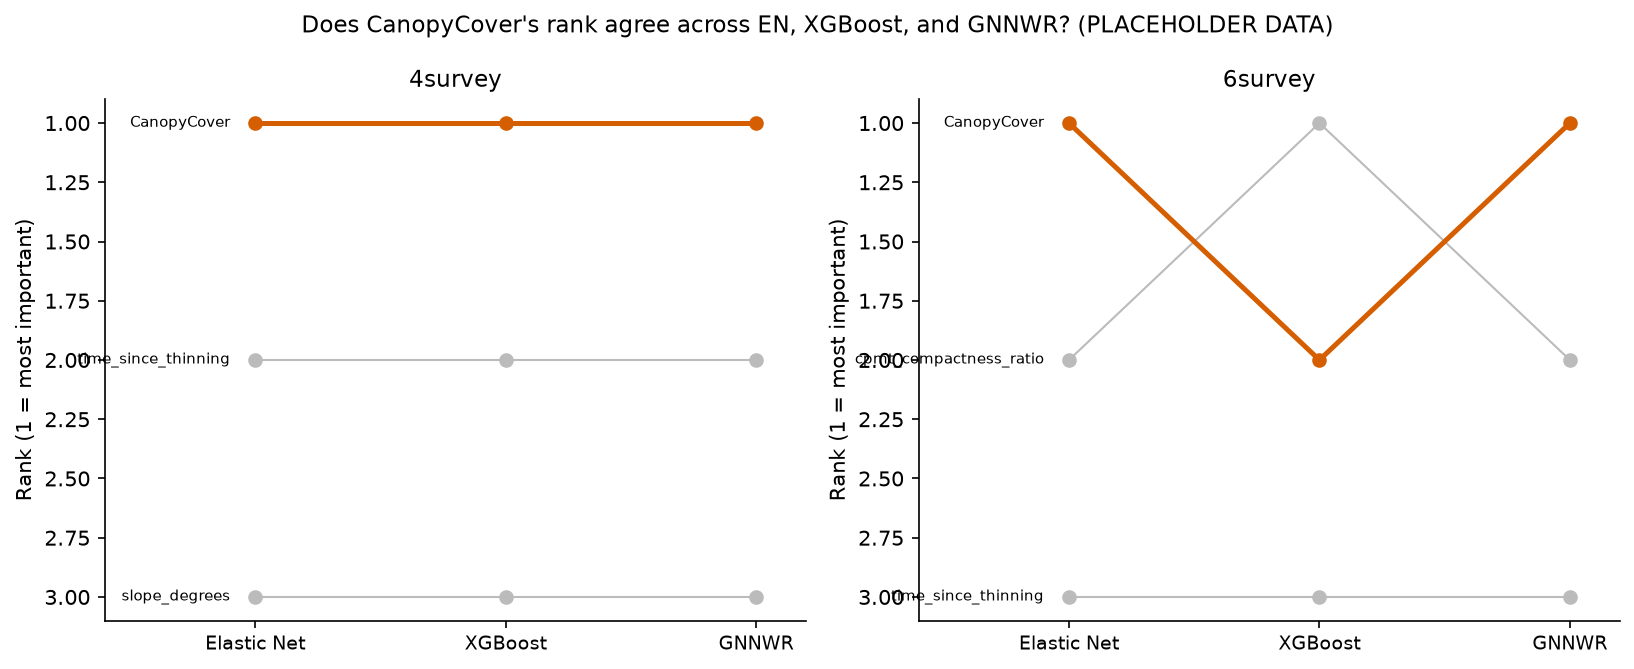

In [9]:
# PLACEHOLDER ranks -- confirm against TEMP_rq3_en_xgb_results_2026-08-11.tex and
# TEMP_rq3_gnnwr_local_coef_rank_2026-08-16.tex before using this figure. Only CanopyCover's own
# rank is asserted with confidence per the source text; the other variables' exact ranks/names
# here are illustrative placeholders standing in for "whatever displaces CanopyCover."
RANKS = {
    "4survey": {"Elastic Net": {"CanopyCover": 1, "time_since_thinning": 2, "slope_degrees": 3},
                "XGBoost": {"CanopyCover": 1, "time_since_thinning": 2, "slope_degrees": 3},
                "GNNWR": {"CanopyCover": 1, "time_since_thinning": 2, "slope_degrees": 3}},
    "6survey": {"Elastic Net": {"CanopyCover": 1, "cpmt_compactness_ratio": 2, "time_since_thinning": 3},
                "XGBoost": {"cpmt_compactness_ratio": 1, "CanopyCover": 2, "time_since_thinning": 3},
                "GNNWR": {"CanopyCover": 1, "cpmt_compactness_ratio": 2, "time_since_thinning": 3}},
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
methods = ["Elastic Net", "XGBoost", "GNNWR"]
for ax, cohort in zip(axes, ["4survey", "6survey"]):
    variables = set()
    for method_ranks in RANKS[cohort].values():
        variables.update(method_ranks.keys())
    for variable in variables:
        ys = [RANKS[cohort][m].get(variable, len(variables) + 1) for m in methods]
        color = COLOR_XGBOOST if variable == "CanopyCover" else "#BBBBBB"
        linewidth = 2.4 if variable == "CanopyCover" else 1.0
        ax.plot(range(3), ys, marker="o", color=color, linewidth=linewidth, zorder=3 if variable == "CanopyCover" else 1)
        ax.text(-0.1, ys[0], variable, ha="right", va="center", fontsize=7)
    ax.set_xticks(range(3))
    ax.set_xticklabels(methods, fontsize=9)
    ax.invert_yaxis()
    ax.set_ylabel("Rank (1 = most important)")
    ax.set_title(cohort, fontsize=11)
    ax.set_xlim(-0.6, 2.2)

fig.suptitle("Does CanopyCover's rank agree across EN, XGBoost, and GNNWR? (PLACEHOLDER DATA)", fontsize=11)
plt.tight_layout()
plt.show()